In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("cleaned_heart.csv")

# preview data
data.head()

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,1,63,145.0,233.0,True,150.0,False,2.3,0,True,False,False,False,False,False,True,False,False,False,False
1,2,67,160.0,286.0,False,108.0,True,1.5,2,True,False,False,False,False,False,False,False,False,True,False
2,3,67,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False,False,False,False,False,True,False
3,4,37,130.0,250.0,False,187.0,False,3.5,0,True,False,False,False,False,True,False,True,False,False,False
4,5,41,130.0,204.0,False,172.0,False,1.4,0,False,False,False,False,True,False,False,False,False,False,True


In [3]:
data['risk'] = data['num'].apply(lambda x: 1 if x > 0 else 0)

data[['num', 'risk']].head()

,num,risk
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [4]:
# columns to drop
drop_cols = ['num', 'risk']

# drop 'id' if it exists
if 'id' in data.columns:
    drop_cols.append('id')

# features and labels
X = data.drop(columns=drop_cols)
y = data['risk']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (920, 18)
Labels shape: (920,)


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,0.714286,0.725,0.386401,1.0,0.633803,0.0,0.556818,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.795918,0.800,0.474295,0.0,0.338028,1.0,0.465909,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.795918,0.600,0.379768,0.0,0.485915,1.0,0.590909,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.183673,0.650,0.414594,0.0,0.894366,0.0,0.693182,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.265306,0.650,0.338308,0.0,0.788732,0.0,0.454545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
def generate_sequences(data, labels, timesteps=5):
    X_seq = []
    y_seq = []

    for i in range(len(data)):
        row = data.iloc[i].values
        sequence = []

        for t in range(timesteps):
            new_step = row.copy()

            # simulate progression
            progression_factor = 1 + (t * 0.03)
            new_step = new_step * progression_factor

            # add small noise
            noise = np.random.normal(0, 0.01, size=row.shape)
            new_step = new_step + noise

            sequence.append(new_step)

        X_seq.append(sequence)
        y_seq.append(labels.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [10]:
timesteps = 5

X_lstm, y_lstm = generate_sequences(X_scaled, y, timesteps)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (920, 5, 18)
y shape: (920,)


In [11]:
# flatten data
X_flat = X_lstm.reshape(X_lstm.shape[0], -1)

# create column names
columns = []
for t in range(timesteps):
    for col in X.columns:
        columns.append(f"{col}_t{t+1}")

# create dataframe
df_lstm = pd.DataFrame(X_flat, columns=columns)
df_lstm['target'] = y_lstm

# save
df_lstm.to_csv("lstm_data.csv", index=False)

print("✅ Saved as lstm_data.csv")

✅ Saved as lstm_data.csv


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [14]:
X = np.load("X_lstm.npy")
y = np.load("y_lstm.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'X_lstm.npy'

In [15]:
np.save("X_lstm.npy", X_lstm)
np.save("y_lstm.npy", y_lstm)

print("✅ Saved as X_lstm.npy and y_lstm.npy")

✅ Saved as X_lstm.npy and y_lstm.npy


In [16]:
import os
os.listdir()

['.ipynb_checkpoints',
 '.venv',
 '.vscode',
 'cleaned_data.csv',
 'cleaned_heart.csv',
 'eda.py',
 'heart.csv',
 'l.py',
 'lstm_data.csv',
 'lstm_model.py',
 'model.pkl',
 'preprocess.py',
 'requirements.txt',
 'train.py',
 'train1.py',
 'Untitled.ipynb',
 'X_lstm.npy',
 'y_lstm.npy']

In [17]:
X = np.load("X_lstm.npy")
y = np.load("y_lstm.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 5, 18)
y shape: (920,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = Sequential()

# LSTM layer
model.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))

# Dropout (helps prevent overfitting)
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\R SAHANA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(X.shape[1], X.shape[2])))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [21]:
model = Sequential()

# LSTM layer
model.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))

# Dropout (helps prevent overfitting)
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6429 - loss: 0.6380 - val_accuracy: 0.8378 - val_loss: 0.5784
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7789 - loss: 0.5371 - val_accuracy: 0.8446 - val_loss: 0.4739
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7891 - loss: 0.4645 - val_accuracy: 0.8649 - val_loss: 0.4258
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8027 - loss: 0.4336 - val_accuracy: 0.8446 - val_loss: 0.4085
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8010 - loss: 0.4277 - val_accuracy: 0.8311 - val_loss: 0.3949
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7857 - loss: 0.4285 - val_accuracy: 0.8514 - val_loss: 0.4020
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8129 - loss: 0.4110 - val_accuracy: 0.8446 - val_loss: 0.3885
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8061 - loss: 0.4170 - val_accuracy: 0.8514 - val_loss

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8098 - loss: 0.3942 
Test Accuracy: 0.8097826242446899


In [24]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Confusion Matrix:
 [[59 16]
 [19 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.77        75
           1       0.85      0.83      0.84       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.81      0.81       184



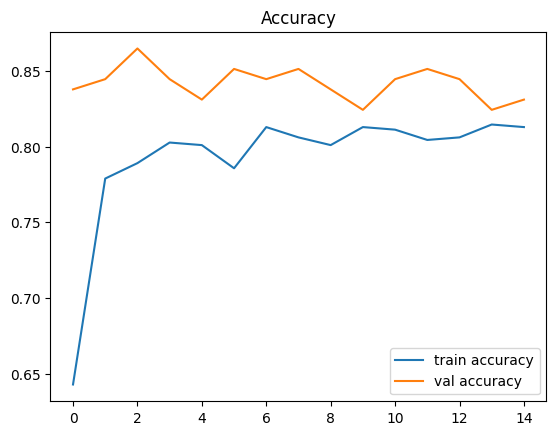

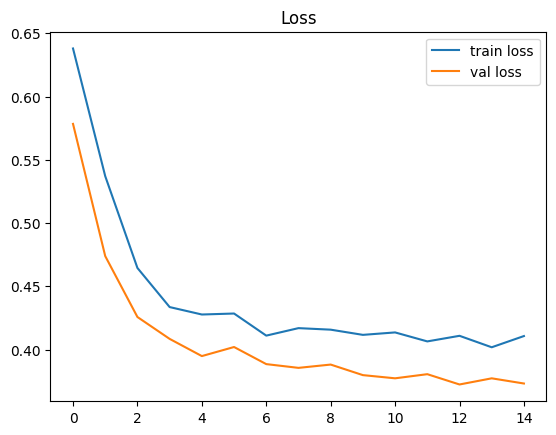

In [25]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [26]:
import numpy as np

unique, counts = np.unique(y_lstm, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 0: 411
Class 1: 509


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [28]:
data = pd.read_csv("cleaned_heart.csv")

data.head()

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,1,63,145.0,233.0,True,150.0,False,2.3,0,True,False,False,False,False,False,True,False,False,False,False
1,2,67,160.0,286.0,False,108.0,True,1.5,2,True,False,False,False,False,False,False,False,False,True,False
2,3,67,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False,False,False,False,False,True,False
3,4,37,130.0,250.0,False,187.0,False,3.5,0,True,False,False,False,False,True,False,True,False,False,False
4,5,41,130.0,204.0,False,172.0,False,1.4,0,False,False,False,False,True,False,False,False,False,False,True


In [29]:
data['risk'] = data['num'].apply(lambda x: 1 if x > 0 else 0)

data[['num', 'risk']].head()

,num,risk
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [30]:
drop_cols = ['num', 'risk']

if 'id' in data.columns:
    drop_cols.append('id')

X = data.drop(columns=drop_cols)
y = data['risk']

print(X.shape, y.shape)

(920, 18) (920,)


In [31]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,0.714286,0.725,0.386401,1.0,0.633803,0.0,0.556818,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.795918,0.800,0.474295,0.0,0.338028,1.0,0.465909,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.795918,0.600,0.379768,0.0,0.485915,1.0,0.590909,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.183673,0.650,0.414594,0.0,0.894366,0.0,0.693182,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.265306,0.650,0.338308,0.0,0.788732,0.0,0.454545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [32]:
def generate_sequences(data, labels, timesteps=10):
    X_seq = []
    y_seq = []

    for i in range(len(data)):
        row = data.iloc[i].values
        sequence = []

        for t in range(timesteps):
            new_step = row.copy()

            # simulate progression
            progression_factor = 1 + (t * 0.03)
            new_step = new_step * progression_factor

            # small noise
            noise = np.random.normal(0, 0.01, size=row.shape)
            new_step = new_step + noise

            sequence.append(new_step)

        X_seq.append(sequence)
        y_seq.append(labels.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [33]:
timesteps = 10

X_lstm, y_lstm = generate_sequences(X_scaled, y, timesteps)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (920, 10, 18)
y shape: (920,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_lstm,
    test_size=0.2,
    random_state=42
)

In [35]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\R SAHANA\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 64)                  │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 64)                  │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.7007 - loss: 0.6109 - val_accuracy: 0.8378 - val_loss: 0.5156
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7976 - loss: 0.4746 - val_accuracy: 0.8041 - val_loss: 0.4101
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7993 - loss: 0.4358 - val_accuracy: 0.8243 - val_loss: 0.4081
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7993 - loss: 0.4337 - val_accuracy: 0.8243 - val_loss: 0.3944
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7976 - loss: 0.4176 - val_accuracy: 0.8311 - val_loss: 0.3859
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8095 - loss: 0.4103 - val_accuracy: 0.8514 - val_loss: 0.3958
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8078 - loss: 0.4030 - val_accuracy: 0.8378 - val_loss: 0.3817
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8197 - loss: 0.4047 - val_accuracy: 0.8446 - v

In [38]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8043 - loss: 0.4114
Test Accuracy: 0.804347813129425


In [39]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Confusion Matrix:
 [[65 10]
 [26 83]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.87      0.78        75
           1       0.89      0.76      0.82       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.82      0.80      0.81       184



In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [41]:
data = pd.read_csv("cleaned_heart.csv")
data.head()

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,1,63,145.0,233.0,True,150.0,False,2.3,0,True,False,False,False,False,False,True,False,False,False,False
1,2,67,160.0,286.0,False,108.0,True,1.5,2,True,False,False,False,False,False,False,False,False,True,False
2,3,67,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False,False,False,False,False,True,False
3,4,37,130.0,250.0,False,187.0,False,3.5,0,True,False,False,False,False,True,False,True,False,False,False
4,5,41,130.0,204.0,False,172.0,False,1.4,0,False,False,False,False,True,False,False,False,False,False,True


In [44]:
data['risk'] = data['num'].apply(lambda x: 1 if x > 0 else 0)

In [45]:
drop_cols = ['num', 'risk']

if 'id' in data.columns:
    drop_cols.append('id')

X = data.drop(columns=drop_cols)
y = data['risk']

In [46]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [47]:
def generate_sequences(data, labels, timesteps=15):
    X_seq = []
    y_seq = []

    for i in range(len(data)):
        row = data.iloc[i].values
        sequence = []

        for t in range(timesteps):
            new_step = row.copy()

            # progression
            progression_factor = 1 + (t * 0.03)
            new_step = new_step * progression_factor

            # noise
            noise = np.random.normal(0, 0.01, size=row.shape)
            new_step = new_step + noise

            sequence.append(new_step)

        X_seq.append(sequence)
        y_seq.append(labels.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [48]:
timesteps = 15

X_lstm, y_lstm = generate_sequences(X_scaled, y, timesteps)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (920, 15, 18)
y shape: (920,)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_lstm,
    test_size=0.2,
    random_state=42
)

In [50]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 64)                  │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.6037 - loss: 0.6388 - val_accuracy: 0.7770 - val_loss: 0.5340
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7823 - loss: 0.4859 - val_accuracy: 0.8581 - val_loss: 0.4077
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8010 - loss: 0.4357 - val_accuracy: 0.8243 - val_loss: 0.4016
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8095 - loss: 0.4243 - val_accuracy: 0.8311 - val_loss: 0.3957
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7976 - loss: 0.4337 - val_accuracy: 0.8446 - val_loss: 0.3929
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8095 - loss: 0.4174 - val_accuracy: 0.8311 - val_loss: 0.3906
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8078 - loss: 0.4101 - val_accuracy: 0.8311 - val_loss: 0.3951
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8129 - loss: 0.4104 - val_accuracy: 0.8581 - v

In [52]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8370 - loss: 0.3913
Test Accuracy: 0.8369565010070801


In [53]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Confusion Matrix:
 [[61 14]
 [16 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80        75
           1       0.87      0.85      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



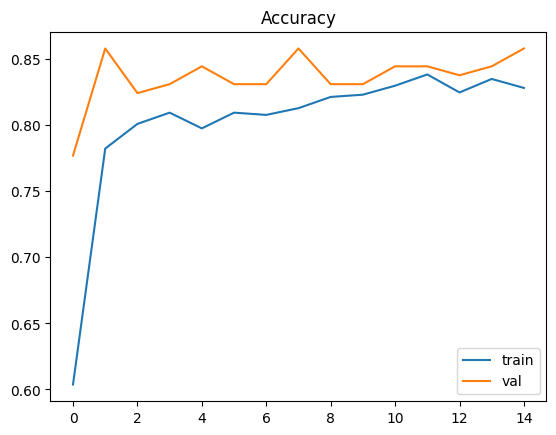

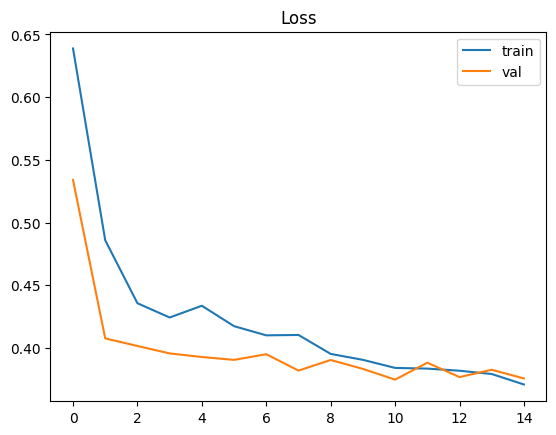

In [54]:
# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [55]:
X.shape = (samples, timesteps, features)

NameError: name 'samples' is not defined

In [56]:
import matplotlib.pyplot as plt

sample = X_lstm[0]  # first patient

# assuming thalach is one of your features
feature_index = list(X.columns).index('thalach')

plt.plot(sample[:, feature_index])
plt.title("Heart Rate Progression")
plt.xlabel("Time Step")
plt.ylabel("Heart Rate")
plt.show()

ValueError: 'thalach' is not in list

In [3]:
# ===============================
# HYPERPARAMETER TUNING
# ===============================
from sklearn.metrics import recall_score

results = []

for units in [32, 64, 128]:
    for dropout in [0.2, 0.3]:

        print(f"\n🔍 Training: units={units}, dropout={dropout}")

        model = Sequential()
        model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
        model.add(LSTM(units))
        model.add(Dropout(dropout))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train, y_train,
            epochs=10,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        # Evaluate
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

        # Predictions
        y_pred = (model.predict(X_test) > 0.5).astype("int32")

        recall = recall_score(y_test, y_pred)

        print(f"✅ Accuracy: {accuracy:.3f}, Recall: {recall:.3f}")

        results.append({
            "units": units,
            "dropout": dropout,
            "accuracy": accuracy,
            "recall": recall
        })


🔍 Training: units=32, dropout=0.2


NameError: name 'X_train' is not defined

In [2]:
# imports (add this at top)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

from sklearn.metrics import recall_score

In [4]:
# ===============================
# HYPERPARAMETER TUNING
# ===============================
from sklearn.metrics import recall_score

results = []

for units in [32, 64, 128]:
    for dropout in [0.2, 0.3]:

        print(f"\n🔍 Training: units={units}, dropout={dropout}")

        model = Sequential()
        model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
        model.add(LSTM(units))
        model.add(Dropout(dropout))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train, y_train,
            epochs=10,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        # Evaluate
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

        # Predictions
        y_pred = (model.predict(X_test) > 0.5).astype("int32")

        recall = recall_score(y_test, y_pred)

        print(f"✅ Accuracy: {accuracy:.3f}, Recall: {recall:.3f}")

        results.append({
            "units": units,
            "dropout": dropout,
            "accuracy": accuracy,
            "recall": recall
        })


🔍 Training: units=32, dropout=0.2


NameError: name 'X_train' is not defined

X shape: (920, 15, 18)
y shape: (920,)

🔍 Training: units=32, dropout=0.2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
✅ Accuracy: 0.821, Recall: 0.862

🔍 Training: units=32, dropout=0.3
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
✅ Accuracy: 0.826, Recall: 0.844

🔍 Training: units=64, dropout=0.2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
✅ Accuracy: 0.832, Recall: 0.862

🔍 Training: units=64, dropout=0.3
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
✅ Accuracy: 0.826, Recall: 0.817

🔍 Training: units=128, dropout=0.2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
✅ Accuracy: 0.783, Recall: 0.725

🔍 Training: units=128, dropout=0.3
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
✅ Accuracy: 0.826, Recall: 0.835

📊 All Results:
    units  dropout  accuracy    recall
0     32      0.2  0.820652  0.862385
1     32      0.3  0.826087  0.844037
2     64      0.2  0.831522  0.862385
3     64      0.3  0.826087  0.816514
4    128      0.2  0.782609  0.724771
5    128      0.3  0.826087  0.834862

🏆 Best Configuration:
 units       32.0

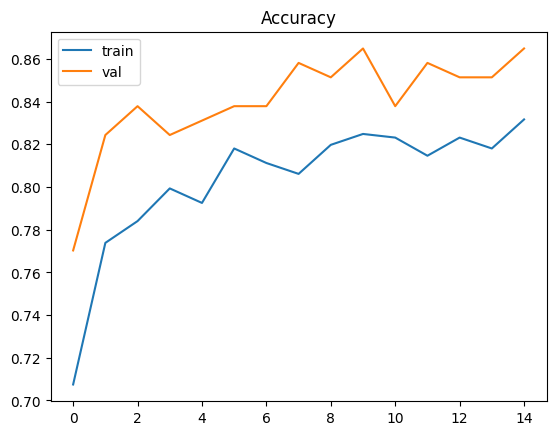

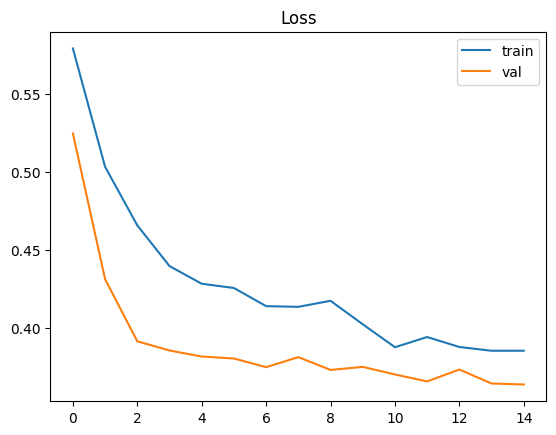


✅ Best model saved as best_lstm_model.h5


In [5]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, recall_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("cleaned_heart.csv")

# ===============================
# CREATE TARGET VARIABLE
# ===============================
data['risk'] = data['num'].apply(lambda x: 1 if x > 0 else 0)

# ===============================
# FEATURES & LABELS
# ===============================
drop_cols = ['num', 'risk']

if 'id' in data.columns:
    drop_cols.append('id')

X = data.drop(columns=drop_cols)
y = data['risk']

# ===============================
# NORMALIZE FEATURES
# ===============================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# ===============================
# GENERATE SEQUENCES
# ===============================
def generate_sequences(data, labels, timesteps=15):
    X_seq = []
    y_seq = []

    for i in range(len(data)):
        row = data.iloc[i].values
        sequence = []

        for t in range(timesteps):
            new_step = row.copy()

            # simulate progression
            progression_factor = 1 + (t * 0.03)
            new_step = new_step * progression_factor

            # add noise
            noise = np.random.normal(0, 0.01, size=row.shape)
            new_step = new_step + noise

            sequence.append(new_step)

        X_seq.append(sequence)
        y_seq.append(labels.iloc[i])

    return np.array(X_seq), np.array(y_seq)

# ===============================
# CREATE LSTM DATA
# ===============================
timesteps = 15

X_lstm, y_lstm = generate_sequences(X_scaled, y, timesteps)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

# ===============================
# TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_lstm,
    test_size=0.2,
    random_state=42
)

# ===============================
# HYPERPARAMETER TUNING
# ===============================
results = []

for units in [32, 64, 128]:
    for dropout in [0.2, 0.3]:

        print(f"\n🔍 Training: units={units}, dropout={dropout}")

        model = Sequential()
        model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
        model.add(LSTM(units))
        model.add(Dropout(dropout))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy']
        )

        model.fit(
            X_train, y_train,
            epochs=10,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        # Evaluate
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

        # Predictions
        y_pred = (model.predict(X_test) > 0.5).astype("int32")

        recall = recall_score(y_test, y_pred)

        print(f"✅ Accuracy: {accuracy:.3f}, Recall: {recall:.3f}")

        results.append({
            "units": units,
            "dropout": dropout,
            "accuracy": accuracy,
            "recall": recall
        })

# ===============================
# RESULTS TABLE
# ===============================
df = pd.DataFrame(results)

print("\n📊 All Results:\n", df)

# Best model (based on recall)
best = df.sort_values(by="recall", ascending=False).iloc[0]

print("\n🏆 Best Configuration:\n", best)

# ===============================
# TRAIN FINAL MODEL
# ===============================
best_units = int(best["units"])
best_dropout = float(best["dropout"])

print(f"\n🚀 Training FINAL model with units={best_units}, dropout={best_dropout}")

model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(best_units))
model.add(Dropout(best_dropout))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

# ===============================
# FINAL EVALUATION
# ===============================
loss, accuracy = model.evaluate(X_test, y_test)

print("\n🎯 Final Test Accuracy:", accuracy)

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# PLOT GRAPHS
# ===============================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

# ===============================
# SAVE MODEL
# ===============================
model.save("best_lstm_model.h5")

print("\n✅ Best model saved as best_lstm_model.h5")

In [1]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

In [2]:
model = load_model("lstm_model_15.h5")
scaler = joblib.load("scaler.pkl")

print("✅ Model and scaler loaded")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'lstm_model_15.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [3]:
import numpy as np
import pandas as pd
import joblib
import os
from tensorflow.keras.models import load_model

In [4]:
print("Current Working Directory:\n", os.getcwd())
print("\nFiles in this folder:\n", os.listdir())

Current Working Directory:
 C:\Users\R SAHANA\OneDrive\Desktop\project\notebooks

Files in this folder:
 ['.ipynb_checkpoints', 'Untitled.ipynb']


In [5]:
model = load_model("lstm_model_15.h5")
scaler = joblib.load("scaler.pkl")

print("✅ Model and scaler loaded successfully")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'lstm_model_15.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [6]:
import os
os.getcwd()

'C:\\Users\\R SAHANA\\OneDrive\\Desktop\\project\\notebooks'

In [7]:
os.listdir()

['.ipynb_checkpoints', 'Untitled.ipynb']

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [ ]:
data = pd.read_csv("cleaned_heart.csv")

print("Shape:", data.shape)
data.head()